# 01 — Dataset Baseline
Establishes ground-truth distributions before factor analysis.


In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from eda.utils import load_tables, enrich_matches, get_working_matches, get_completed_maps, savefig

tables = load_tables()
matches_raw = tables['matches']
matches = enrich_matches(matches_raw)
working = get_working_matches(matches)
comp_maps = get_completed_maps(tables['maps'], working)


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/01_bestof_by_tier.png


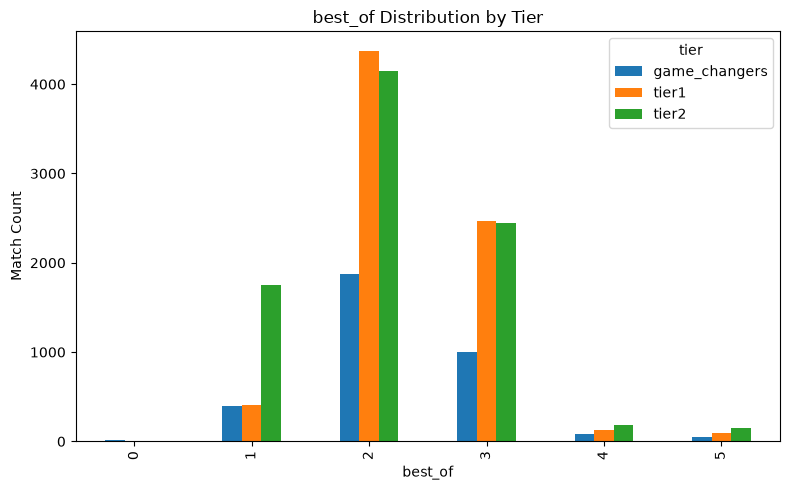

In [2]:
# 1a. best_of distribution by tier
fig, ax = plt.subplots(figsize=(8,5))
bo_counts = working.groupby(['tier','best_of']).size().unstack(fill_value=0)
bo_counts.T.plot(kind='bar', ax=ax)
ax.set_title('best_of Distribution by Tier')
ax.set_xlabel('best_of')
ax.set_ylabel('Match Count')
plt.tight_layout()
savefig(fig, '01_bestof_by_tier')
plt.show()


CT win rate by tier:
tier
game_changers    0.486140
tier1            0.500018
tier2            0.492627
Name: winning_side, dtype: float64


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/01_ct_winrate_by_tier.png


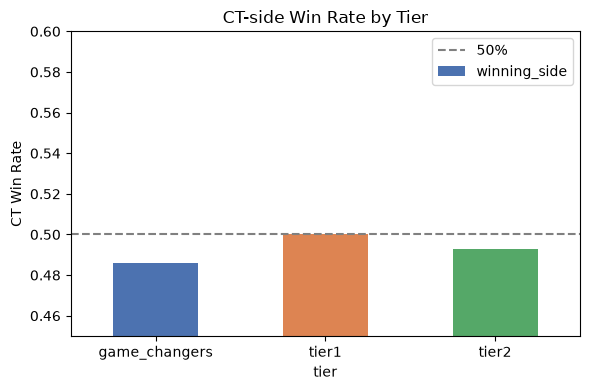

In [3]:
# 1b. CT vs T win rate by tier (from map_rounds)
rounds = tables['map_rounds'].merge(
    working[['match_id','tier']], on='match_id', how='inner'
)
ct_wr = rounds.groupby('tier')['winning_side'].apply(lambda s: (s=='ct').mean())
print("CT win rate by tier:")
print(ct_wr)

fig, ax = plt.subplots(figsize=(6,4))
ct_wr.plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.axhline(0.5, color='gray', linestyle='--', label='50%')
ax.set_ylim(0.45, 0.60)
ax.set_title('CT-side Win Rate by Tier')
ax.set_ylabel('CT Win Rate')
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
savefig(fig, '01_ct_winrate_by_tier')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/01_map_volume_by_tier.png


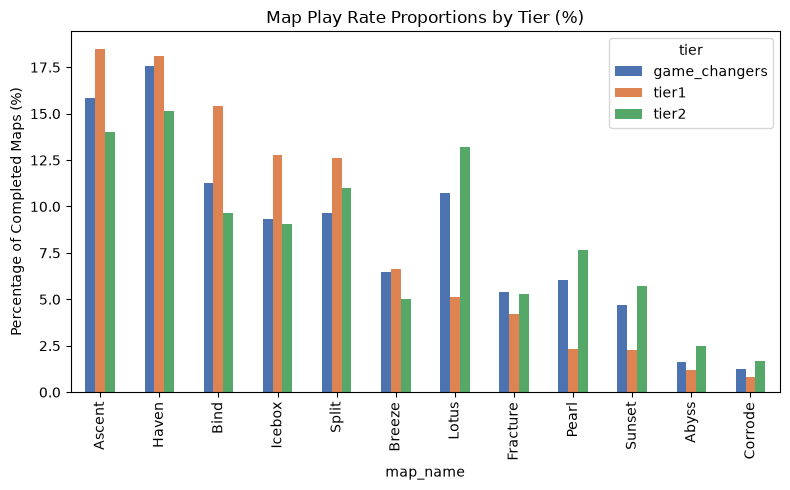

In [4]:
# %%[markdown]
# 1c. Map play rate proportions by tier
fig, ax = plt.subplots(figsize=(8,5))
map_counts = comp_maps.groupby(['tier','map_name']).size().unstack(fill_value=0)
map_props = map_counts.div(map_counts.sum(axis=1), axis=0) * 100
map_props.T.sort_values('tier1', ascending=False).plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title('Map Play Rate Proportions by Tier (%)')
ax.set_ylabel('Percentage of Completed Maps (%)')
plt.tight_layout()
savefig(fig, '01_map_volume_by_tier')
plt.show()


Saved → /Users/francis/school/y2/t3/model/valorant/eda/figures/01_patch_timeline.png


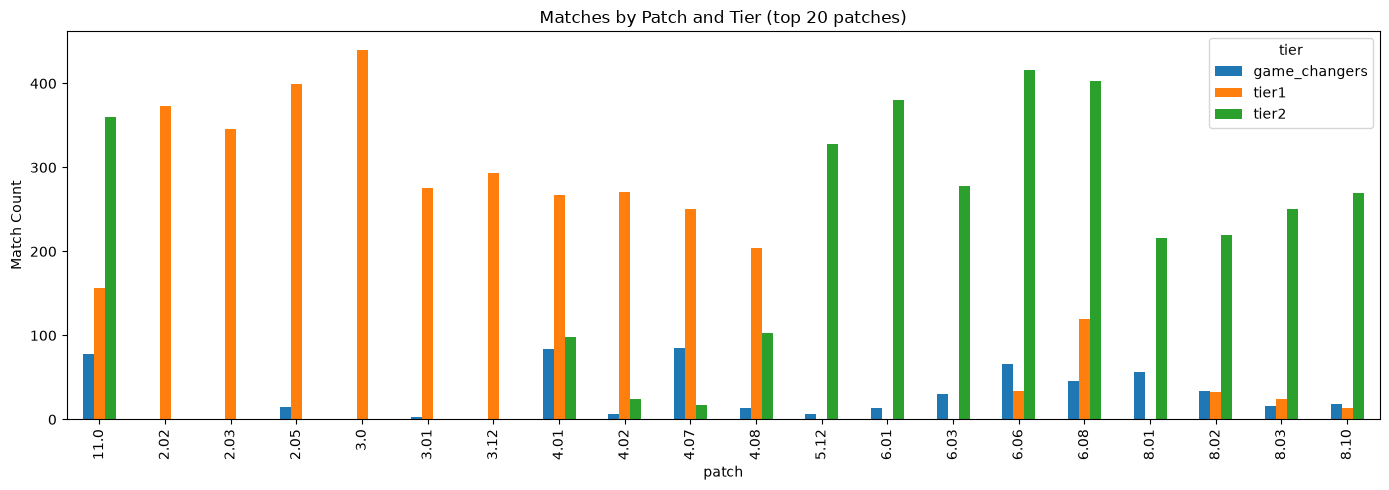

In [5]:
# 1d. Patch timeline: match count by patch × tier (top 20 patches)
top_patches = working['patch'].value_counts().head(20).index
patch_tier = (working[working['patch'].isin(top_patches)]
              .groupby(['patch','tier']).size().unstack(fill_value=0))
fig, ax = plt.subplots(figsize=(14,5))
patch_tier.plot(kind='bar', ax=ax, stacked=False)
ax.set_title('Matches by Patch and Tier (top 20 patches)')
ax.set_ylabel('Match Count')
plt.tight_layout()
savefig(fig, '01_patch_timeline')
plt.show()
